# Práctica 3 de resolución numérica de ecuaciones no lineales

## ¿Resolución de ecuaciones o cálculo de raíces?
Los métodos numéricos que veremos a continuación devuelven aproximaciones de las raíces de funciones de una variable, pero esto es equivalente a resolver una ecuación. Por ejemplo:
- hallar las soluciones de la ecuación $\sin(x)-5x = 2$ es equivalente a
- hallar las raíces de la función $f(x) = \sin(x)-5x-2$.

En algunos métodos la convergencia no está garantizada. Por eso conviene conocer de antemano si la raíz de la función existe en el intervalo estudiado (aplicando el teorema de Bolzano) e idealmente si la raíz es única en el intervalo (aplicando el teorema de Rolle).

## Resolución con `find_root`
SageMath cuenta con el comando de cálculo numérico `find_root` para aproximar las raíces de una función. Como ejemplo, tomamos la función $f(x) = \cos(x) - \sin(x)$ en $[-2, 2]$; la raíz es $\frac{\pi}{4}\approx 0.785398163397448$.

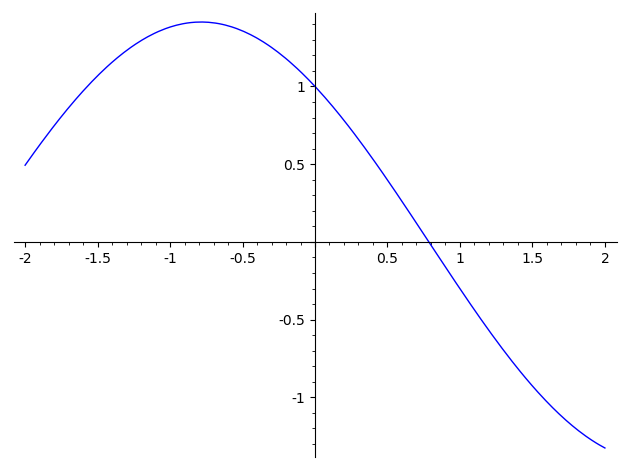

In [1]:
f = lambda x: cos(x)-sin(x)
plot(f, -2, 2)

In [2]:
find_root(f, -2, 2), RDF(pi/4)

(0.7853981633974474, 0.7853981633974483)

El comando `find_root` constrye los iterantes de una sucesión $x_1, x_2, \ldots, x_{n},x_{n+1},\ldots$ hasta que algún criterio de parada se cumple. En la imagen siguiente vemos el <span style="color:red">criterio del resíduo</span> y el <span style="color:green">criterio de iterantes próximos</span>: 

<img src="criterios.png" width="60%" align="center">

<!-- 
f(x) = 1-x^2-x^4
plot(f, -.05, .8, ticks=[[0.2,0.5],None], tick_formatter=[["",""],None]) + \
line([(0.5,0),(0.5,f(0.5))], color='red', linestyle='--') + \
line([(0.495,0.01),(0.505,0.01)], color='red') + \
line([(0.495,f(0.5)),(0.505,f(0.5))], color='red') + \
text(r'$|f(x_{n+1})|< rtol?$', (0.62, 0.15), fontsize=14,color='red') + \
text(r'$x_{n+1}$', (0.5, -0.05), fontsize=14,color='black') + \
text(r'$x_{n}$',   (0.2, -0.05), fontsize=14,color='black') + \
line([(0.2,-0.1),(0.5,-0.1)], color='green', linestyle='--') + \
text(r'$|x_{n+1}-x_n|< xtol?$', (0.35, -0.17), fontsize=14,color='green') + \
line([(0.2,-0.11),(0.2,-0.09)], color='green') + \
line([(0.5,-0.11),(0.5,-0.09)], color='green') + \
text(r'$\alpha$', (0.77, -0.03), color='black', fontsize=14)
-->

Al cambiar los [argumentos opcionales de `find_root`](https://doc.sagemath.org/html/en/reference/numerical/sage/numerical/optimize.html), la aproximación cambia.

In [3]:
r1 = find_root(f, -2, 2, rtol=1e-6)
r2 = find_root(f, -2, 2, rtol=1e-10)
RDF(abs(r1-pi/4)), RDF(abs(r2-pi/4))

(9.420608926280494e-08, 8.881784197001252e-16)

## El método de dicotomía
Veamos el código que implementa el método de dicotomía que converge siempre que la función sea continua y tenga alternancia de signo en los extremos del intervalo.

In [4]:
def dicotomia(f, a, b, xtol=1e-12, rtol=1e-12):
    """DICOTOMIA    Calculo de raíces por el método de dicotomia."""
    fa = RDF(f(a))
    fb = RDF(f(b))
    # comprobaciones previas
    if abs(fa) < rtol:
        return RDF(a), 0
    elif abs(fb) < rtol:
        return RDF(b), 0
    elif fa*fb > 0:
        raise RuntimeError('La función presenta el mismo signo en ambos extremos.')
    # calculo iterativo
    maxit = ceil(log((b-a)/xtol, 2) - 1)
    for it in range(maxit):
        c  = RDF((a+b)/2)
        fc = RDF(f(c))
        if abs(fc) < rtol:
            return c, it
        elif fa*fc < 0:
            b  = c
            fb = fc
        else:
            a = c
            fa = fc
    return c, it

Veamos si en en el ejemplo anterior puede devolver una raíz y en cuántas iteraciones.

In [5]:
dicotomia(f, -2, 2)

(0.7853981633979856, 40)

Como en `find_root`, la precisión al calcular la ríaz puede cambiarse con los argumentos opcionales `xtol`y `rtol`.

In [6]:
dicotomia(f, -2, 2, rtol = 1e-6)

(0.7853984832763672, 20)

**Ejercicio 1:**
1. Halla intervalos donde las raíces de $\displaystyle y = \frac{4}{3}x^4 - \frac{8}{15}x^3 - \frac{23}{25}x^2 + \frac{73}{375}x - \frac{37}{3750}$ sean únicas. Aplica el comando `find_root` y el método de dicotomía para hallarlas.
<!-- f(x) = 4/3*(x-0.1)^4-(x-0.1)^2 -->

Empezamos ver la gráfica para intuir en qué intervalos las raíces son únicas.

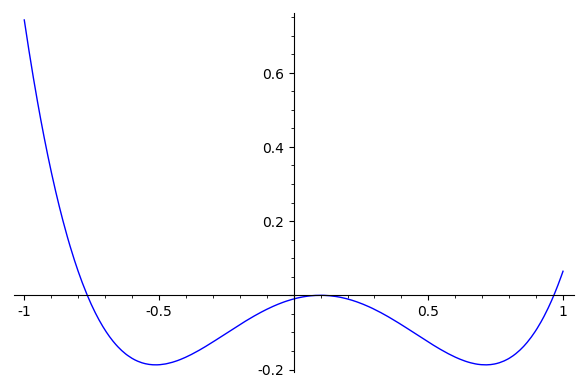

In [7]:
g = lambda x: 4/3*x^4 - 8/15*x^3 - 23/25*x^2 + 73/375*x - 37/3750
plot(g, -1, 1)

Evaluamos la función en $x=-1,-0.7,0.9,1$:

In [8]:
g(-1), g(-0.7), g(0.9), g(1)

(2783/3750, -0.0938666666666667, -0.0938666666666668, 81/1250)

La función es continua en todo $\mathbb{R}$ por ser un polinomio. Por el teorema de Bolzano, existen raíces en $[-1,-0.7]$ y en $[0.9,1]$, pues hai alternacia de signo de $f$ en los extremos. Parece haber otra raíz (doble) cerca de $0.1$, pero no se puede asegurar pues no hai alternancia de signo en sus cercanías.  

Además, por el teorema de Rolle, las dos primeras raíces son úncias en sus intervalos, ya que la derivada no se anula al ser monótona.  

Ahora usaremos `find_root` para identificar las raíces en $[-1,-0.7]$ e $[0.9,1]$, y la posible raíz cerca de de 0.1.

In [9]:
find_root(g, -1, -0.7), find_root(g, 0.9, 1), find_root(g, 0, 0.3)

(-0.7660254037844334, 0.9660254037844188, 0.09999999999993447)

Finalmente, probamos con `dicotomía`.

In [10]:
dicotomia(g, -1, -0.7)

(-0.7660254037840784, 37)

In [11]:
dicotomia(g, 0.9, 1)

(0.9660254037837149, 35)

Las dos primeras raíces las calcula bien. Sin embargo, no puede calcular la tercera pues no se da alternancia de signo en las cercanías de la raíz.

In [12]:
dicotomia(g, 0, 0.3)

RuntimeError: La función presenta el mismo signo en ambos extremos.

## El método de Newton
Programa aquí el método de Newton con la siguiente cabecera:
```python
def newton(f, df, x0, xtol=1e-12, rtol=1e-14, M=100):```
donde `f` y `df`son la función y su derivada, `x0` es el iterante inicial y `M` es el número máximo de iteraciones. `xtol` y `rtol` tienen el mismo significado que antes. El resultado debe ser la aproximación de la raíz y el número de iteraciones realizado.

In [1]:
def newton(f, df, x0, xtol=1e-12, rtol=1e-14, M=100):
    """NEWTON    Calculo de raices por Newton."""
    for k in range(M):
        dfx0 = RDF(df(x0))
        if abs(dfx0) < rtol:
            raise RuntimeError('La derivada se anula en un iterante.')
        r = RDF(x0 - f(x0) / dfx0)
        # test de parada
        if abs(r-x0) < xtol or abs(f(r)) < rtol: 
            return r, k+1
        x0 = r
    raise RuntimeError('Excedido el número máximo de iteraciones.')

Para aproximar una raíz con el método anterior, debemos tener de antemano la derivada de $f$, o una forma de calcularla.

In [2]:
f = lambda x: cos(x)-sin(x)
var('x')
df(x) = diff(f(x), x)
newton(f, df, 0)

(0.7853981633974483, 4)

### Orden de convergencia del método de Newton
El método de Newton puede llegar a convergencia cuadrática, lo que implica que existen $N$, $C$ constantes positivas para las que:

$$|\alpha-x_{n+1}| \leq C|\alpha-x_n|^2,\ n\geq N, $$

siendo $\alpha$ la raíz exacta. Para comprobar en la práctica que la converxencia es cuadrática, podemos dibujar las constantes $C_n$ para comprobar si permanecen acotadas cuando $n$ crece:

$$ C_n = \frac{|\alpha-x_{n+1}|}{|\alpha-x_n|^2}.$$

Para ello, debemos modificar el método de Newton para que devuelva, como tercer argumento de salida, la lista de iterantes hasta convergencia. Empieza por guardar el primer iterante con `v = [RDF(x0)]` y luego añadir cada iterante calculado a la lista, con `v.append(r)`.

In [3]:
def newton(f, df, x0, xtol=1e-12, rtol=1e-14, M=100):
    """NEWTON    Calculo de raices por Newton."""
    v = [RDF(x0)]
    for k in range(M):
        dfx0 = RDF(df(x0))
        if abs(dfx0) < rtol:
            raise RuntimeError('La derivada se anula en un iterante.')
        r = RDF(x0 - f(x0) / dfx0)
        v.append(r)
        # test de parada
        if abs(r-x0) < xtol or abs(f(r)) < rtol: 
            return r, len(v), v
        x0 = r
    raise RuntimeError('Excedido el número máximo de iteraciones.')

La siguiente función representa las constantes $C_n$ frente a la iteraciones calculadas, siempre que el denominador no sea excesivamente pequeño. La raíz exacta se aproxima con `find_root`.

In [4]:
def coef_newton(f, a, b, v):
    """COEF_NEWTON    Gráfica de los coeficientes de convergencia de Newton."""
    alpha = find_root(f, a, b, xtol=9.e-16, rtol=9.e-16) # aproximamos "al máximo" la raíz
    pts = []
    for n in range(len(v)-1):
        if (alpha - v[n])^2 > RDF.epsilon():
            pts.append( (n, abs(alpha - v[n+1]) / (alpha - v[n])^2 ) )
    return line(pts, marker = '.', title='Coeficientes $C_n$')

Ahora llamamos a Newton para obtener la lista de iterantes y representamos las constantes de convergencia.

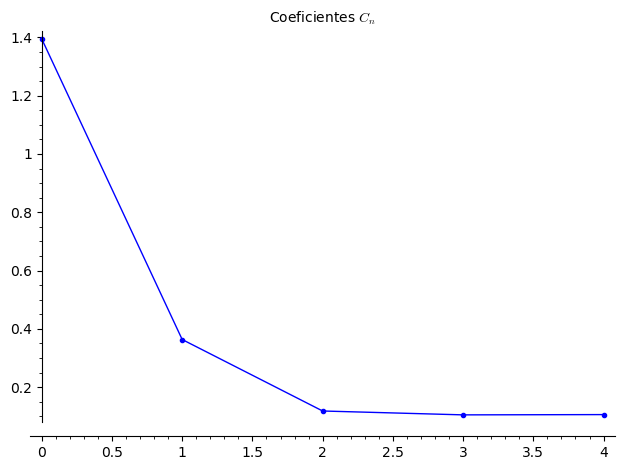

In [5]:
r,k,v = newton(f, df, -1.1)
coef_newton(f, -2, 2, v)

En la gráfica se observa que, cuando $n$ crece, las constantes $C_n$ tienden a converger a un valor algo menor que $0.1$. Por tanto, la convergencia es cuadrática.

**Ejercicio 2:**
1. Halla una aproximación de las tres raíces de $\displaystyle y = \frac{4}{3}x^4 - \frac{8}{15}x^3 - \frac{23}{25}x^2 + \frac{73}{375}x - \frac{37}{3750}$ mediante `newton` e indica en cuántes iteraciones se consigue. Comprueba si la convergencia es cuadrática en las tres.
<!-- f(x) = 4/3*(x-0.1)^4-(x-0.1)^2 -->

In [20]:
g = lambda x: 4/3*x^4 - 8/15*x^3 - 23/25*x^2 + 73/375*x - 37/3750
var('x')
dg(x) = diff(g(x), x)
# primera raíz
r,k,v = newton(g, dg, -1)
r,k

(-0.7660254037844386, 6)

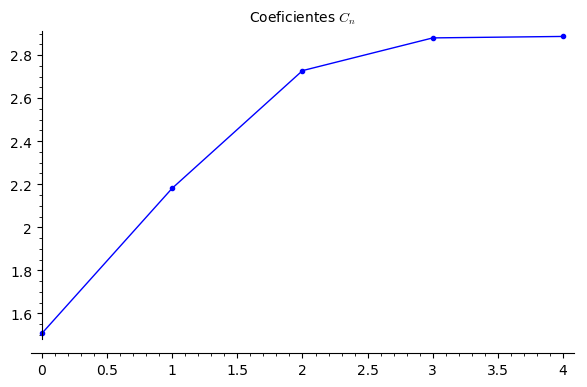

In [21]:
coef_newton(g, -1, -0.7, v)

Compróbase que los coeficientes se estabilizan alrededor de $3$, por lo que la convergencia es cuadrática.

In [22]:
# segunda raíz
r,k,v = newton(g, dg, 0)
r,k

(0.09999990635833783, 20)

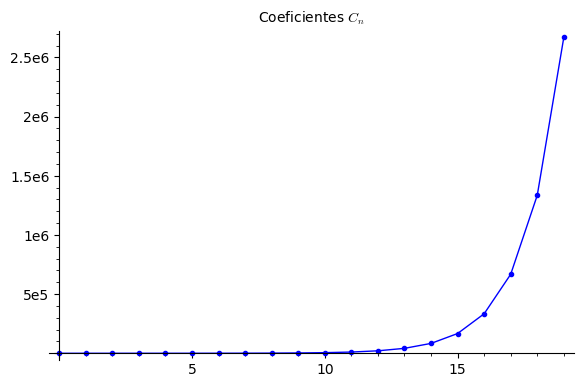

In [23]:
coef_newton(g, 0, 0.11, v)

En este caso, los coeficientes no están acotados según $n$ crece; la converxencia NO es cuadrática.

In [24]:
# tercera raíz
r,k,v = newton(g, dg, 1.2)
r,k

(0.9660254037844387, 6)

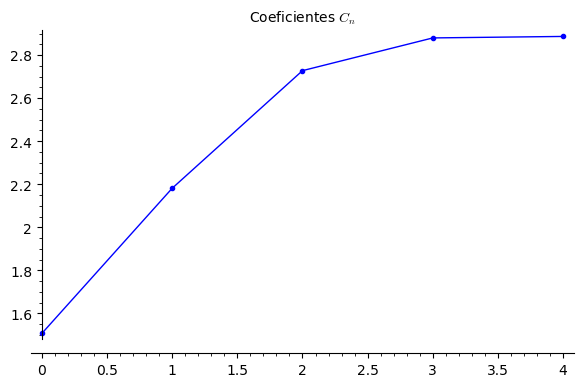

In [25]:
coef_newton(g, 0.95, 1, v)

Hay convergencia cuadrática como en la primera raíz.

**Exercicio adicional:** 
1. Identifica un intervalo en el que la función siguiente tenga una raíz:    
$h(x) =\begin{cases}
    -\sqrt{\pi-x}, & \text{ se }x < \pi, \\
    \sqrt{x-\pi}, & \text{ en otro caso}. \end{cases}$  
2. Intenta calcular la raíz con `find_root` y `dicotomia`.
3. Intenta aplicar el método de Newton para intentar calcular la raíz. Como $h$ no es una expresión simbólica, debes derivar cada rama de la función y construir con el resultado cada rama de la función derivada `df`. No es correcto poner el comando `diff` dentro de las ramas de `df`.  

**Observación**: Este es un ejemplo donde Newton no es convergente, para cualquier iterante inicial. Observa que, aunque la función es continua, su derivada no está acotada en un entorno de la raíz.

<img src="newton_no_converge.png" width="60%" align="center">

**Solución**: La gráfica nos ayuda a identificar un intervalo conteniendo una raíz:

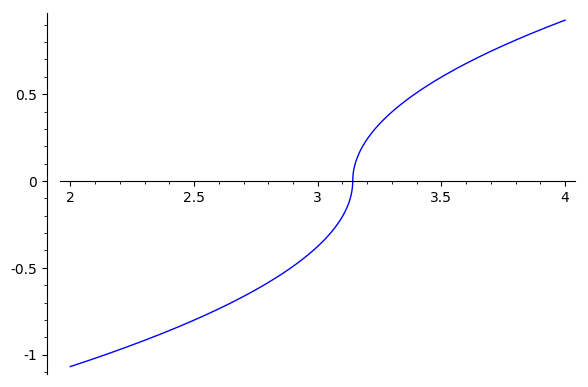

In [13]:
def h(x):
    if x < pi: 
        return -sqrt(pi-x)
    else:
        return sqrt(x-pi)
plot(h, 2, 4)

Las dos ramas de la función son continuas en sus intervalos de definición por ser raíces con radicandos no negativos. Además, los límites laterales en $x=\pi$ existen y coinciden. Como hay alternacia de signo en $[2,4]$, por Bolzano se puede afirmar que hay al menos unha raíz en ese intervalo. Sin embargo, la función no é derivable en $x=\pi$, luego no aplica el terorema de Rolle en ningún intervalo conteniendo a $\pi$.

Tanto `find_root` como `dicotomia` devuelven la aproximación de la raíz en $\pi$.

In [14]:
find_root(h, 2, 4), dicotomia(h, 2, 4)[0]

(3.141592653589879, 3.1415926535901235)

Para usar Newton, derivamos cada rama de la función e construímos con ellas (copiándolas e pegándolas) la función derivada:

In [27]:
diff(-sqrt(pi-x)) #derivada en (-oo, pi)

1/2/sqrt(pi - x)

In [28]:
diff(sqrt(x-pi)) #derivada en [pi, +-oo)

1/2/sqrt(-pi + x)

In [29]:
def dh(x):
    if x < pi: 
        return 1/2/sqrt(pi - x) #pegado do resultado de diff
    else:
        return 1/2/sqrt(-pi + x) #idem

Agora podemos llamar a `newton`:

In [30]:
newton(h, dh, 3)

RuntimeError: Excedido el número máximo de iteraciones.